In [35]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from scipy.io import readsav
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from astropy.wcs import WCS
from astropy.wcs.utils import pixel_to_skycoord
import cv2

In [5]:
d= readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI4\bxyz_map.sav')
# IDL 变量名在 Python 里通常会变成小写
print(d.keys())   # 先看实际键名

mapbx = d["mapbx"][0][0]
mapby = d["mapby"][0][0]
mapbz = d["mapbz"][0][0]

dict_keys(['mapbx', 'mapby', 'mapbz'])


In [6]:
print(mapbx.mean(),mapby.mean(),mapbz.mean())

0.79626274 -2.182541 3216412.0


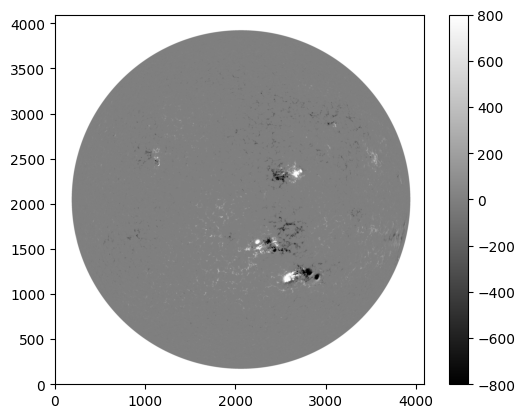

In [17]:
plt.imshow(mapbz,origin='lower',cmap='gray',vmin=-800,vmax=800)
plt.colorbar()

尝试3，看看直接从头文件得到的$\phi_0$,b,p和从坐标得到的一不一样

尝试2，将Python中.rotate后的结果插值回4096*4096，然后再看看得到的结果

In [ ]:
#成功了！！！！！！！！！！！！！！！！！！！！！！！！
hmi_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_720s\\'
B_map_4098 = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.field.fits').rotate()
B_map_data=B_map_4098.data
B_map_data=cv2.resize(B_map_data,(4096,4096),interpolation=cv2.INTER_AREA)
B_map=sunpy.map.Map(B_map_data,B_map_4098.meta)
inc_map_4098 = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.inclination.fits').rotate()
inc_map_data=inc_map_4098.data
inc_map_data=cv2.resize(inc_map_data,(4096,4096),interpolation=cv2.INTER_AREA)
inc_map=sunpy.map.Map(inc_map_data,inc_map_4098.meta)
azi_map_4098 = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.azimuth.fits').rotate()
azi_map_data=azi_map_4098.data
azi_map_data=cv2.resize(azi_map_data,(4096,4096),interpolation=cv2.INTER_AREA)
azi_map=sunpy.map.Map(azi_map_data,azi_map_4098.meta)

In [44]:
# 1 获取 header 参数
phi0 = B_map.observer_coordinate.lon.to(u.rad).value
b    = B_map.observer_coordinate.lat.to(u.rad).value
# WCS rotation matrix
pc = B_map.wcs.wcs.pc

# P-angle（弧度）
p = np.arctan2(pc[0,1], pc[0,0])

# 2 像素坐标
ny,nx = B_map.data.shape
y,x = np.mgrid[0:ny,0:nx]

# 3 skycoord
coords = pixel_to_skycoord(x,y,B_map.wcs)

# 4 heliographic
hg = coords.transform_to(frames.HeliographicStonyhurst)

phi = hg.lon.to(u.rad).value
lam = hg.lat.to(u.rad).value

# phi=phi+np.pi
# phi=np.mod(phi, 2*np.pi)
# lam=-lam

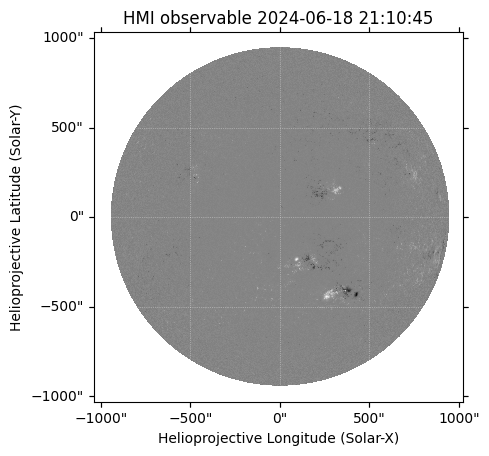

In [ ]:
#计算矩阵参数
dphi = phi - phi0

k11 = np.cos(lam)*(np.sin(b)*np.sin(p)*np.cos(dphi) + np.cos(p)*np.sin(dphi)) \
      - np.sin(lam)*(np.cos(b)*np.sin(p))

k12 = -np.cos(lam)*(np.sin(b)*np.cos(p)*np.cos(dphi) - np.sin(p)*np.sin(dphi)) \
      + np.sin(lam)*(np.cos(b)*np.cos(p))

k13 = np.cos(lam)*np.cos(b)*np.cos(dphi) + np.sin(lam)*np.sin(b)


k21 = np.sin(lam)*(np.sin(b)*np.sin(p)*np.cos(dphi) + np.cos(p)*np.sin(dphi)) \
      + np.cos(lam)*(np.cos(b)*np.sin(p))

k22 = -np.sin(lam)*(np.sin(b)*np.cos(p)*np.cos(dphi) - np.sin(p)*np.sin(dphi)) \
      - np.cos(lam)*(np.cos(b)*np.cos(p))

k23 = np.sin(lam)*np.cos(b)*np.cos(dphi) - np.cos(lam)*np.sin(b)


k31 = -np.sin(b)*np.sin(p)*np.sin(dphi) + np.cos(p)*np.cos(dphi)

k32 =  np.sin(b)*np.cos(p)*np.sin(dphi) + np.sin(p)*np.cos(dphi)

k33 = -np.cos(b)*np.sin(dphi)
#这个Bx,By,Bz应该就是mapbx,mapby,mapbz，不知道为什么丢了一块
Br =(k11*Bx + k12*By + k13*Bz)
Btheta = k21*Bx + k22*By + k23*Bz
Bphi = k31*Bx + k32*By + k33*Bz

B_map_rot=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.field.fits').rotate()
Br_map=sunpy.map.Map(Br,B_map_rot.meta)
Br_map.plot()

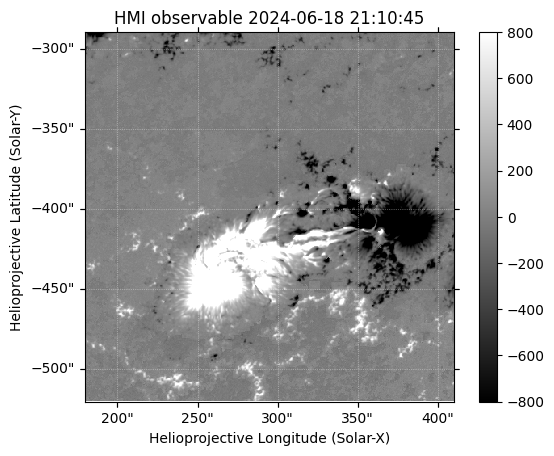

In [46]:
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=Br_map.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=Br_map.coordinate_frame)
sub_map=Br_map.submap(bottom_left,top_right=top_right)
im=sub_map.plot()
im.set_clim(-800,800)
plt.colorbar(im)

In [47]:
Br_map.save(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI4\Br_map.fits',overwrite=True)